<a href="https://colab.research.google.com/github/Dairo-Delgadillo-DEv/ML_House_Prices_Prediction/blob/main/ML_House_California_Predict.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
from sklearn.datasets import fetch_california_housing
import pandas as pd

# 1. Fetch the real California Housing  dataset
california = fetch_california_housing(as_frame=True)

# 2. Convert it into a Pandas DataFrame
df_california = california.frame

# 3. rename columns to make them friendlier
df_california.rename(columns={"MedHouseVal": "Price_100k_USD"}, inplace=True)

print("--- 1. Dataset Shape (Rows, Columns) ---")
print(df_california.shape)

print("\n--- 2. First 5 Rows of Real Data ---")
print(df_california.head())

--- 1. Dataset Shape (Rows, Columns) ---
(20640, 9)

--- 2. First 5 Rows of Real Data ---
   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  Price_100k_USD  
0    -122.23           4.526  
1    -122.22           3.585  
2    -122.24           3.521  
3    -122.25           3.413  
4    -122.25           3.422  


--- 1. Statistical Summary ---
             MedInc      HouseAge      AveRooms     AveBedrms    Population  \
count  20640.000000  20640.000000  20640.000000  20640.000000  20640.000000   
mean       3.870671     28.639486      5.429000      1.096675   1425.476744   
std        1.899822     12.585558      2.474173      0.473911   1132.462122   
min        0.499900      1.000000      0.846154      0.333333      3.000000   
25%        2.563400     18.000000      4.440716      1.006079    787.000000   
50%        3.534800     29.000000      5.229129      1.048780   1166.000000   
75%        4.743250     37.000000      6.052381      1.099526   1725.000000   
max       15.000100     52.000000    141.909091     34.066667  35682.000000   

           AveOccup      Latitude     Longitude  Price_100k_USD  
count  20640.000000  20640.000000  20640.000000    20640.000000  
mean       3.070655     35.631861   -119.569704        2.068558  
std       10.386050      2.135952      2.003532        1.15

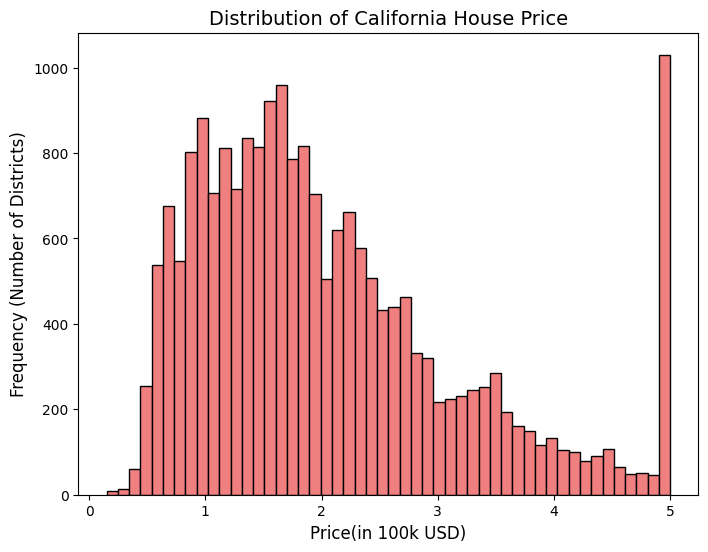

In [3]:
import matplotlib.pyplot as plt

# 1. Generate statistical summary of the dataset
print("--- 1. Statistical Summary ---")
print(df_california.describe())

# 2. Plot a histogram of the house prices
plt.figure(figsize=(8, 6))
plt.hist(df_california["Price_100k_USD"], bins=50, color="lightcoral", edgecolor="black")

# 3. Add labels and title
plt.title("Distribution of California House Price", fontsize=14)
plt.xlabel("Price(in 100k USD)", fontsize=12)
plt.ylabel("Frequency (Number of Districts)", fontsize=12)

# 4. Show the plot
plt.show()

In [5]:
# 1. Calculate the correlation matrix for all metrical columns
correlation_matrix = df_california.corr()

# 2. Extract only the correlation values relative to our target 'Price_100k_USD'
# We sort them in descencing order to see the strongest relationships first
price_correlation = correlation_matrix["Price_100k_USD"].sort_values(ascending=False)

print("--- Correlation with House Price ---")
print(price_correlation)

--- Correlation with House Price ---
Price_100k_USD    1.000000
MedInc            0.688075
AveRooms          0.151948
HouseAge          0.105623
AveOccup         -0.023737
Population       -0.024650
Longitude        -0.045967
AveBedrms        -0.046701
Latitude         -0.144160
Name: Price_100k_USD, dtype: float64


In [6]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error

# 1. Prepare features (x) and targets (y)
# We use 'MedInc' because it has the strongest correlation!
x = df_california[["MedInc"]]
y = df_california["Price_100k_USD"]

# 2. Split into training (80%) and testing (20%)
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

# 3. Train Model
california_model = LinearRegression()
california_model.fit(x_train, y_train)

# 4. Predict on test data
predictions = california_model.predict(x_test)

# 5. Evaluate the error (MAE)
mae = mean_absolute_error(y_test, predictions)

print("--- California Model Trained ---")
print(f"Mean Absolute Error (MAE): {mae:.4f} (in 100k USD)")
# Since prices are in 100k USD, let's convert the error to actual dollars
print(f"Averange Error in real Dollars: ${mae * 100000:,.2f} USD")

--- California Model Trained ---
Mean Absolute Error (MAE): 0.6299 (in 100k USD)
Averange Error in real Dollars: $62,990.87 USD
